# Complaint Prediction Project using Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import joblib

from google.colab import files


In [2]:
uploaded = files.upload()

Saving expanded_historical_complaints_dataset.csv to expanded_historical_complaints_dataset.csv


In [3]:
df = pd.read_csv("expanded_historical_complaints_dataset.csv")

df.head()


,Problem_Name,Problem_Category,Ministry,Minister_Name,Days_To_Complete
0,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
1,Government housing delay,housing,minister for housing and urban development,S Muthusamy,10
2,Government housing delay,housing,minister for housing and urban development,S Muthusamy,6
3,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4
4,Government housing delay,housing,minister for housing and urban development,S Muthusamy,4


In [4]:
category_encoder = LabelEncoder()

ministry_encoder = LabelEncoder()

minister_encoder = LabelEncoder()


In [5]:
df["Problem_Category"] = category_encoder.fit_transform(
    df["Problem_Category"]
)

df["Ministry"] = ministry_encoder.fit_transform(
    df["Ministry"]
)

df["Minister_Name"] = minister_encoder.fit_transform(
    df["Minister_Name"]
)

df.head()


,Problem_Name,Problem_Category,Ministry,Minister_Name,Days_To_Complete
0,Government housing delay,6,5,9,4
1,Government housing delay,6,5,9,10
2,Government housing delay,6,5,9,6
3,Government housing delay,6,5,9,4
4,Government housing delay,6,5,9,4


In [6]:
X = df[[
    "Problem_Category",
    "Ministry",
    "Minister_Name"
]]

y = df["Days_To_Complete"]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)


In [8]:
regressor = LinearRegression()


In [9]:
regressor.fit(X_train, y_train)


LinearRegression()

In [10]:
y_pred = regressor.predict(X_test)

print(y_pred)


[16.51121702 17.91982059 17.15921081 ... 16.83475088 17.15921081
 16.83475088]


In [11]:
score = regressor.score(X_test, y_test)

print("Score :", score)


Score : 0.004116190649756768


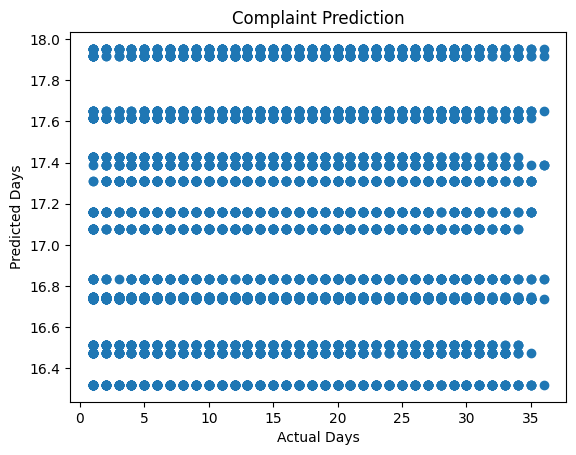

In [12]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Days")

plt.ylabel("Predicted Days")

plt.title("Complaint Prediction")

plt.show()


In [13]:
joblib.dump(
    regressor,
    "complaint_prediction_model.joblib"
)

print("Model Saved Successfully")


Model Saved Successfully


In [14]:
import os

os.listdir()


['.config',
 'expanded_historical_complaints_dataset.csv',
 'complaint_prediction_model.joblib',
 'sample_data']

In [15]:
files.download(
    "complaint_prediction_model.joblib"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Predict New Complaint

In [16]:
problem_category = category_encoder.transform(
    ["transport"]
)[0]

ministry = ministry_encoder.transform(
    ["minister for transport"]
)[0]

minister = minister_encoder.transform(
    ["SR Rajakannappan"]
)[0]


In [17]:
sample = [[
    problem_category,
    ministry,
    minister
]]


In [18]:
prediction = regressor.predict(sample)

print(
    "Predicted Days To Complete :",
    prediction[0]
)


Predicted Days To Complete : 16.471497633871397


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
